In [ ]:
import os
import sys
sys.path.append('../')
import numpy as np
import matplotlib.pyplot as plt
import os
from pydicom import dcmread
import torch

from types import MappingProxyType

from pydose_rt import ModelConfig
from pydose_rt.engine.data import DataGenerator
import engine.utils.plot_utils as plot_utils


from models.simple_dose_model import *

/home/rd/anaconda3/envs/autoplan/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/rd/anaconda3/envs/autoplan/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:404: UserWarning: <built-in function array> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(


In [2]:
notebook_dir = os.getcwd()
parent_dir = os.path.dirname(notebook_dir)
data_path = os.path.join(parent_dir, "database/AUTORPT/")
gen = DataGenerator(data_path, "plotting", True, 1)

Number of files: 1 in plotting cohort


In [3]:
def prepare_real(is_hu=False):
    T = TestSetup(
        parent_dir=parent_dir,
        # filedir="database/testsetup/pytorch_b003_bs01_f10_v16_d04_ptv100_fixed_DoseEngine/data_00_c1.npz",
    )
    T.create_dummy(number_of_leaf_pairs=128, number_of_cps=15)

    ct = T.ct  # numpy array
    ct_np = ct
    ptv = T.data["masks"][0, ..., 0]

    ct_np = downsample_ct_by_2(ct_np)  # Assumes it returns a numpy array
    ptv = downsample_ct_by_2(ptv)  # Assumes it returns a numpy array
    X, Y, Z = ct_np.shape
    ct_torch = torch.tensor(ct_np, dtype=torch.float32)

    if is_hu:
        # Convert normalized CT back to HU
        HU_MIN = -1000
        HU_MAX = 3000
        ct_torch = ((ct_torch + 1) / 2) * (HU_MAX - HU_MIN) + HU_MIN
    return ct_torch, ptv, X, Y, Z

In [4]:
batch_size = 1
number_of_cps = 180
num_leafs = 60
# voxel_sizes = (1.0, 1.0, 1.0)  # mm
voxel_sizes = tuple([0.75 / 60 * num_leafs for i in range(3)])  # mm
# voxel_sizes = tuple([0.1 for i in range(3)])  # mm
dx, dy, dz = voxel_sizes
device = "cuda" if torch.cuda.is_available() else "cpu"

ct_data, ptv, W, D, H = prepare_real(is_hu=False)

T = TestSetup(
    parent_dir=parent_dir,
    # filedir="database/testsetup/pytorch_b003_bs01_f10_v16_d04_ptv100_fixed_DoseEngine/data_00_c1.npz",
    # filedir="database/testsetup/pytorch_b007_bs01_f16_v16_d04_ptv100_fixed_DoseEngineBroadBeamMLC/data_00_c1.npz",
)
T.create_real()

config = ModelConfig(
    ct_array_shape=(W, D, H),
    number_of_leaf_pairs=num_leafs,
    number_of_cps=number_of_cps,
    field_size=(num_leafs * 1.0, num_leafs * 1.0),
    resolution=voxel_sizes,
    tpr_20_10=0.72,
)

ct_data = ct_data.unsqueeze(0).expand(batch_size, -1, -1, -1)

iso_x = (W // 2) * dx
iso_y = (D // 2) * dy
iso_z = (H // 2) * dz

beam_angles = np.tile(
    np.linspace(0, 360, number_of_cps, endpoint=False), (batch_size, 1)
)


Number of files: 1 in plotting cohort
Number of files: 1 in plotting cohort


In [5]:
mlc_leafs = np.zeros((batch_size, number_of_cps, num_leafs, 2))

# Calculate which leaves are inside the field
leaf_width_v = 1.0  # Assuming leaf width from the engine
v_min_total = -(num_leafs / 2) * leaf_width_v

for leaf_idx in range(num_leafs):
    # max_positive_extent = 10.0  # Maximum positive displacement for leaf_idx, 1
    # if leaf_idx % 8 < 4:
    #     mlc_leafs[:, :, leaf_idx, 0] = -max_positive_extent
    #     mlc_leafs[:, :, leaf_idx, 1] = max_positive_extent
    # else:
    #     mlc_leafs[:, :, leaf_idx, 0] = 0
    #     mlc_leafs[:, :, leaf_idx, 1] = 0
    
    mlc_leafs[:, :, leaf_idx, 0] = -10
    mlc_leafs[:, :, leaf_idx, 1] = 10
        

mus = np.ones((batch_size, number_of_cps)) * 1.0 / 0.38 / number_of_cps

In [6]:
print_processing("compute_dose (batched with penumbra)")

engine = DoseEngine(
    config,
    leaf_width=1,
    # ssd=2000.0,
    voxel_sizes=voxel_sizes,
    device=device,
)

engine = DoseEngineDense(
    config,
    leaf_width=1,
    # ssd=2000.0,
    voxel_sizes=voxel_sizes,
    device=device,
)

isocenter = np.array(
    [iso_x, iso_y, iso_z],
    dtype=np.float32,
)
ptv = torch.tensor(ptv, device=device)
valid_leaf = compute_valid_leaf_mask(
    ptv,  # [W, D, H] boolean PTV mask in voxel-indices
    config,
)
print(valid_leaf)

valid_leaf_expanded = valid_leaf.unsqueeze(-1)

_mlc_leafs = np.copy(mlc_leafs)
mlc_leafs = torch.tensor(_mlc_leafs, device=device)

mlc_leafs = torch.tensor(_mlc_leafs, device=device) * valid_leaf_expanded
# mlc_leafs_all = torch.tensor(_mlc_leafs, device=device)



dose_3d = engine(
    ct_data=ct_data,
    beam_angles=beam_angles,
    mlc_leafs=mlc_leafs,
    mus=mus,
    kernel_sigma=2.0,  # Controls penumbra width in mm. Try values from 1.0 to 5.0
)

print(f"Dose shape: {dose_3d.shape}")


>> processing compute_dose (batched with penumbra)
tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], device='cuda:0', dtype=torch.uint8)


/home/rd/anaconda3/envs/autoplan/lib/python3.11/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")


Dose shape: torch.Size([1, 64, 64, 160])


Dose shape: torch.Size([1, 64, 64, 160])

--- Batch 0 ---
Sample dose at isocenter (32, 32, 80): 3.672614 Gy


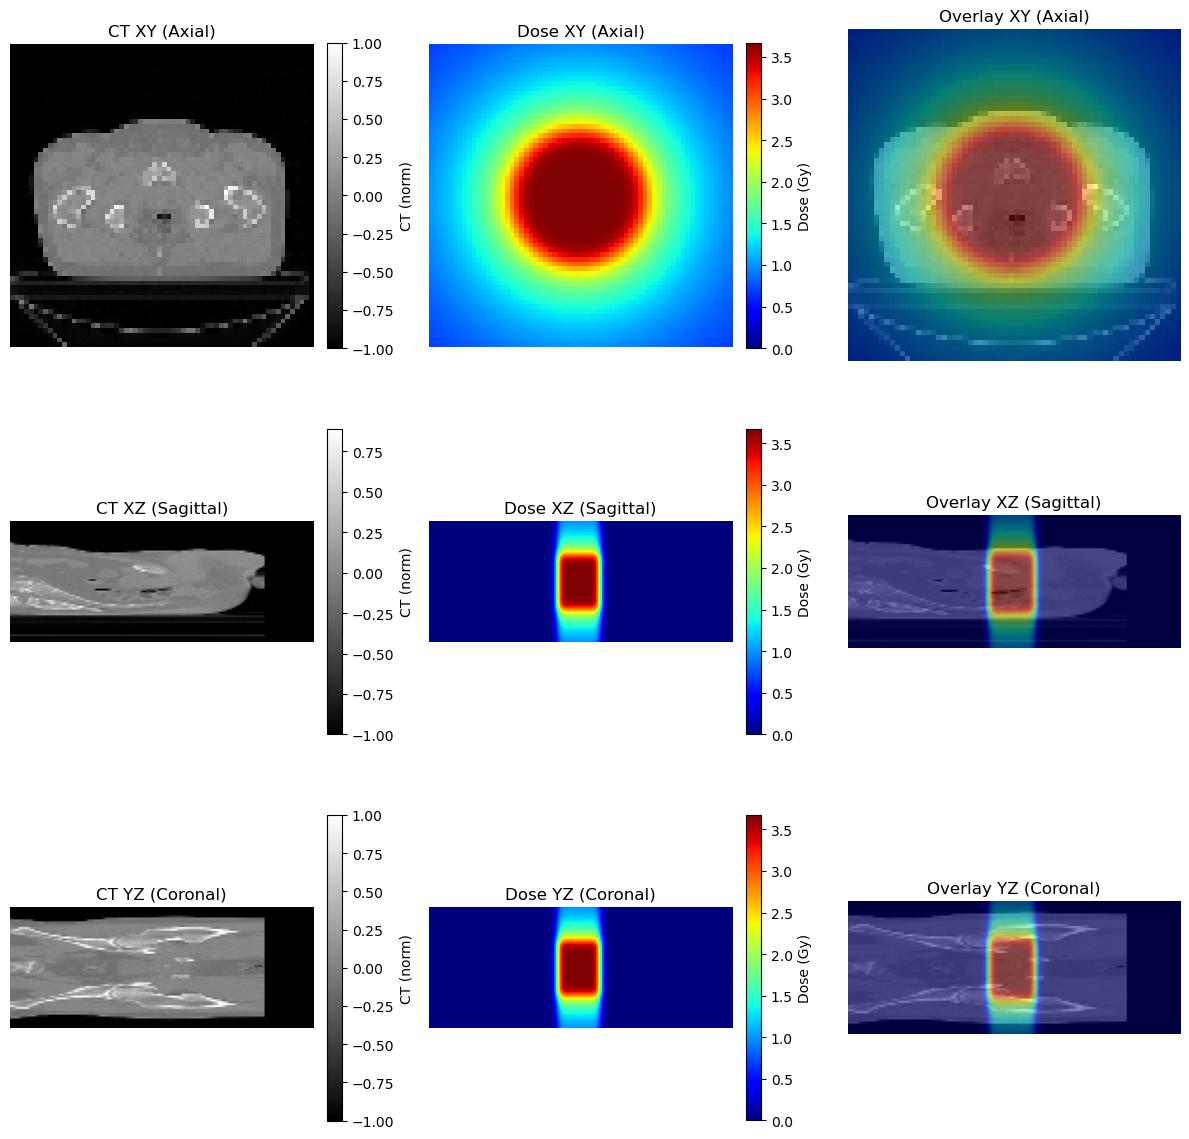

In [7]:
print(f"Dose shape: {dose_3d.shape}")

for b in range(batch_size):
    print(f"\n--- Batch {b} ---")
    mid_x, mid_y, mid_z = int(iso_x / dx), int(iso_y / dy), int(iso_z / dz)
    print(
        f"Sample dose at isocenter ({mid_x}, {mid_y}, {mid_z}): {dose_3d[b, mid_x, mid_y, mid_z]:.6f} Gy"
    )

    ct_np = ct_data[b].cpu().numpy()
    engine.plot_ct_and_dose_slices(
        ct_np=ct_np,
        dose_list=[dose_3d[b].cpu().numpy()],
        slice_indices=(mid_x, mid_y, mid_z),
    )
